# 00 · Data statistics

Per-target library statistics for the 8 MF-PCBA targets, the nested train/eval split used for fine-tuning, and validation against the paper's Table 1. Ends with a look at the **highest-affinity molecules** (top Boltz-2 binding probability) and confirmed actives.

In [1]:
import os, gzip, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 40)

ROOT = Path("/global/scratch/users/sergiomar10/boltzaff")
RAW  = ROOT / "data" / "mf-pcba_test"       # distributed per-target CSVs
DATA = ROOT / "data"                        # our cleaned CSVs + seqs + MSAs
SPLITS = ROOT / "BoltzFT" / "data" / "splits"

# target folder -> (protein, source structure/GI)
TARGETS = {
 "588689":         ("Dengue-2 NS5 MTase",      "PDB 3EVG"),
 "540297-493091":  ("SCP1 phosphatase",        "PDB 3PGL"),
 "434954-2097":    ("GSK-3\u03b2",               "PDB 1J1B"),
 "463203-2650":    ("GSK-3\u03b1",               "PDB 7SXF"),
 "493248-485317":  ("ALR / GFER oxidase",      "PDB 3MBG"),
 "504329":         ("Influenza A NS1",         "predicted (GI 227977143)"),
 "624273-588549":  ("M.tb FadD28 ligase",      "predicted (GI 1781172)"),
 "1053173-743445": ("NSD2 PWWP1 domain",       "PDB 6UE6"),
}

# Paper Table 1 (Furui & Ohue, arXiv:2609.24302), for validation.
# target -> dict(neval, nactive_eval, active_rate_pct, train_actives {40,100,300})
PAPER_T1 = {
 "588689":        dict(neval=49685, nact=396, rate=0.80, tr={40:16,100:32,300:90}),
 "540297-493091": dict(neval=49685, nact=739, rate=1.49, tr={40:8, 100:16,300:43}),
 "434954-2097":   dict(neval=49615, nact=415, rate=0.84, tr={40:24,100:52,300:107}),
 "463203-2650":   dict(neval=49582, nact=542, rate=1.09, tr={40:13,100:29,300:70}),
 "493248-485317": dict(neval=49680, nact=953, rate=1.92, tr={40:1, 100:9, 300:23}),
 "504329":        dict(neval=49682, nact=438, rate=0.88, tr={40:4, 100:11,300:28}),
 "624273-588549": dict(neval=49687, nact=150, rate=0.30, tr={40:4, 100:4, 300:9}),
 "1053173-743445":dict(neval=49695, nact=134, rate=0.27, tr={40:0, 100:5, 300:10}),
}

def load_split_order(t):
    """Return the score_boltz2-descending CID ranking shipped in data/splits."""
    p = SPLITS / f"{t}.txt.gz"
    with gzip.open(p, "rt") as f:
        return [int(x.strip().removeprefix(t + "_")) for x in f]


In [2]:
import matplotlib as mpl, matplotlib.pyplot as plt
PALETTE = ["#2a78d6","#eb6834","#1baf7a","#eda100","#e87ba4","#008300","#4a3aa7","#e34948"]
INK, MUTED, SURF = "#0b0b0b", "#52514e", "#fcfcfb"
ACTIVE, INACTIVE, BLUE = "#e34948", "#b8b6ad", "#2a78d6"
TCOLOR = {t: PALETTE[i] for i, t in enumerate(TARGETS)}   # fixed hue per target
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 100})


In [3]:
def target_frame(t):
    df = pd.read_csv(DATA / f"{t}_results.csv")
    order = load_split_order(t)
    df = df.set_index("CID").loc[order].reset_index()   # Boltz-2 ranked
    df["rank"] = np.arange(1, len(df) + 1)
    return df
frames = {t: target_frame(t) for t in TARGETS}
print("loaded", len(frames), "targets")

loaded 8 targets


## Library size, actives, and the nested split
Training compounds are the **top-N** of the Boltz-2 ranking (N=40/100/300, nested); the common evaluation set excludes the top 300. We compare our counts to the paper's Table 1.

In [4]:
rows = []
for t, df in frames.items():
    total, act = len(df), int(df.Active_v2.sum())
    eval_df = df.iloc[300:]
    tr = {n: int(df.iloc[:n].Active_v2.sum()) for n in (40, 100, 300)}
    p = PAPER_T1[t]
    rows.append({"target": t, "protein": TARGETS[t][0],
        "n_total": total, "n_active": act, "active_rate_%": round(100*act/total, 2),
        "n_eval": len(eval_df), "n_eval(paper)": p["neval"],
        "nact_eval": int(eval_df.Active_v2.sum()), "nact_eval(paper)": p["nact"],
        "tr40": tr[40], "tr100": tr[100], "tr300": tr[300],
        "tr(paper)": "/".join(str(p["tr"][n]) for n in (40,100,300))})
stat = pd.DataFrame(rows)
stat

,target,protein,n_total,n_active,active_rate_%,n_eval,n_eval(paper),nact_eval,nact_eval(paper),tr40,tr100,tr300,tr(paper)
0,588689,Dengue-2 NS5 MTase,49985,486,0.97,49685,49685,396,396,16,32,90,16/32/90
1,540297-493091,SCP1 phosphatase,49985,782,1.56,49685,49685,739,739,8,16,43,8/16/43
2,434954-2097,GSK-3β,49915,522,1.05,49615,49615,415,415,24,52,107,24/52/107
3,463203-2650,GSK-3α,49882,612,1.23,49582,49582,542,542,13,29,70,13/29/70
4,493248-485317,ALR / GFER oxidase,49980,976,1.95,49680,49680,953,953,1,9,23,1/9/23
5,504329,Influenza A NS1,49982,466,0.93,49682,49682,438,438,4,11,28,4/11/28
6,624273-588549,M.tb FadD28 ligase,49987,159,0.32,49687,49687,150,150,4,4,9,4/4/9
7,1053173-743445,NSD2 PWWP1 domain,49995,144,0.29,49695,49695,134,134,0,5,10,0/5/10


In [5]:
# Hard validation against the paper
ok = True
for t, df in frames.items():
    p = PAPER_T1[t]; eval_df = df.iloc[300:]
    ok &= (len(eval_df) == p["neval"]) and (int(eval_df.Active_v2.sum()) == p["nact"])
    ok &= all(int(df.iloc[:n].Active_v2.sum()) == p["tr"][n] for n in (40,100,300))
print("all 8 targets match paper Table 1 (neval, nactive, train actives):", ok)

all 8 targets match paper Table 1 (neval, nactive, train actives): True


## Active rate per target
MF-PCBA is dominated by inactives (0.27%–1.92% active) — this is why *early* enrichment matters.

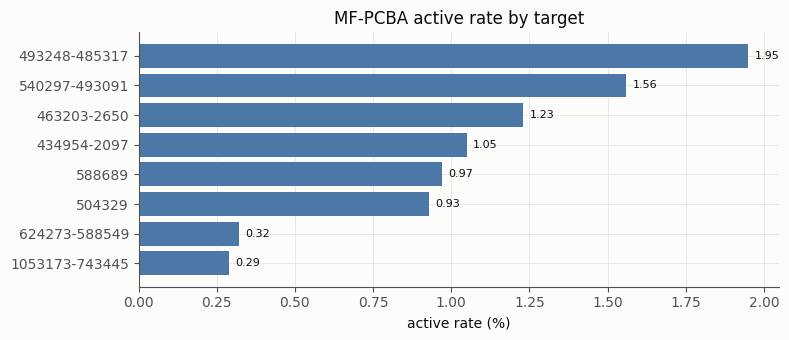

In [6]:
import matplotlib.pyplot as plt
rates = stat.set_index("target")["active_rate_%"].sort_values()
fig, ax = plt.subplots(figsize=(8,3.5))
ax.barh(range(len(rates)), rates.values, color="#4C78A8")
ax.set_yticks(range(len(rates))); ax.set_yticklabels(rates.index)
ax.set_xlabel("active rate (%)"); ax.set_title("MF-PCBA active rate by target")
for i,v in enumerate(rates.values): ax.text(v+0.02, i, f"{v:.2f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## Where do the actives fall in the Boltz-2 (No-FT) ranking?
The cumulative recovery of actives vs. rank. A curve bowed toward the top-left means the off-the-shelf Boltz-2 score already enriches actives early — the baseline that fine-tuning aims to improve.

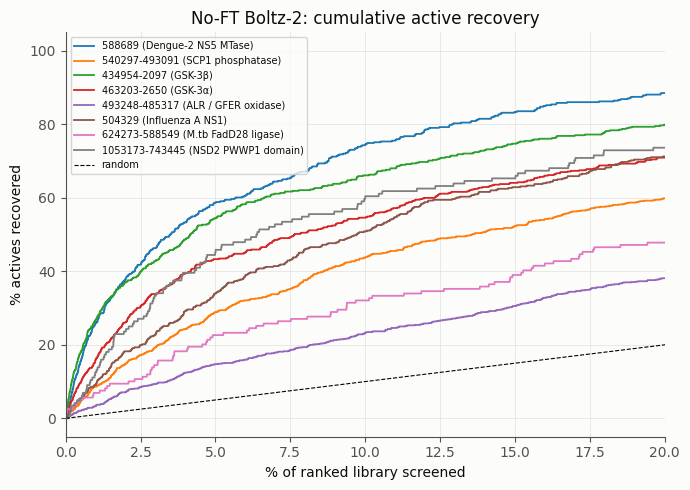

In [7]:
fig, ax = plt.subplots(figsize=(7,5))
for t, df in frames.items():
    y = np.cumsum(df.Active_v2.values) / df.Active_v2.sum()
    ax.plot(np.arange(1,len(df)+1)/len(df)*100, y*100, label=f"{t} ({TARGETS[t][0]})", lw=1.3)
ax.plot([0,100],[0,100], "k--", lw=0.8, label="random")
ax.set_xlabel("% of ranked library screened"); ax.set_ylabel("% actives recovered")
ax.set_title("No-FT Boltz-2: cumulative active recovery"); ax.set_xlim(0,20); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Boltz-2 score distribution: actives vs inactives (588689)

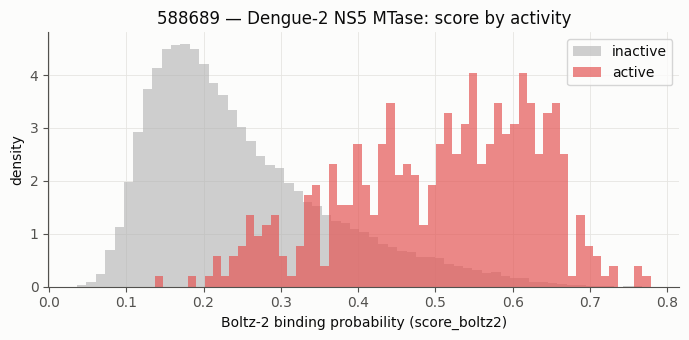

In [8]:
t="588689"; df=frames[t]
fig,ax=plt.subplots(figsize=(7,3.5))
ax.hist(df[df.Active_v2==0].affinity_probability_binary, bins=60, alpha=.6, density=True, label="inactive", color="#B0B0B0")
ax.hist(df[df.Active_v2==1].affinity_probability_binary, bins=60, alpha=.7, density=True, label="active", color="#E45756")
ax.set_xlabel("Boltz-2 binding probability (score_boltz2)"); ax.set_ylabel("density")
ax.set_title(f"{t} — {TARGETS[t][0]}: score by activity"); ax.legend()
plt.tight_layout(); plt.show()

## High-affinity molecules
The top compounds by Boltz-2 binding probability for 588689. Green = confirmed active, red = inactive (a false positive at the top of the No-FT ranking — exactly the compounds whose labels fine-tuning learns from).

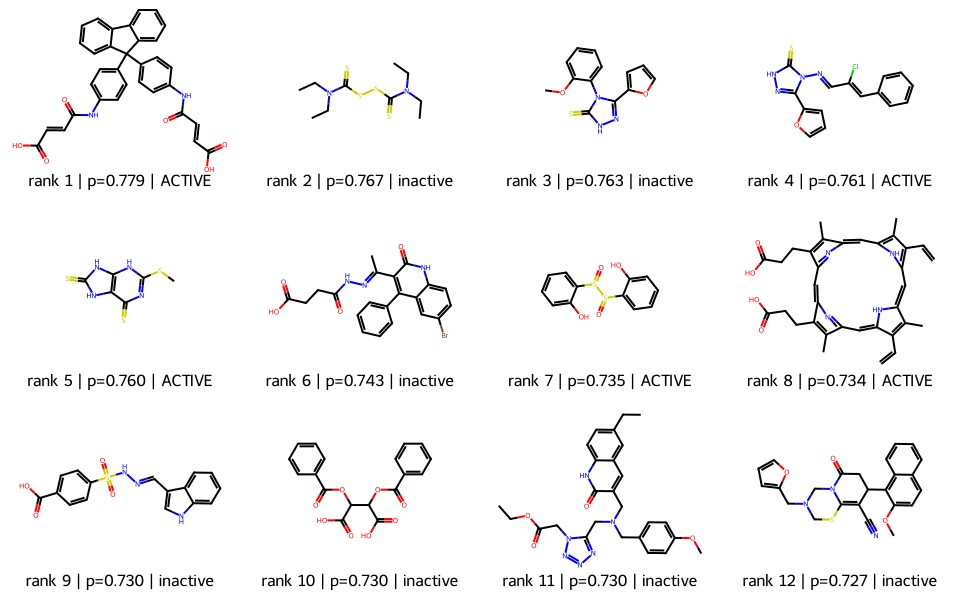

In [9]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors
from rdkit.Chem.Draw import rdMolDraw2D
import warnings; warnings.filterwarnings("ignore")

t="588689"; df=frames[t]
top = df.head(12)
mols, legends, colors = [], [], []
for _, r in top.iterrows():
    m = Chem.MolFromSmiles(str(r["neut-smiles"]))
    if m is None: continue
    mols.append(m)
    rk = int(r["rank"]); lab = "ACTIVE" if r.Active_v2==1 else "inactive"
    legends.append(f"rank {rk} | p={r.affinity_probability_binary:.3f} | {lab}")
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(240,200), legends=legends)
img

## Highest-scoring **confirmed actives** (588689)
The true positives Boltz-2 already ranks well — chemically, what this target's binders look like.

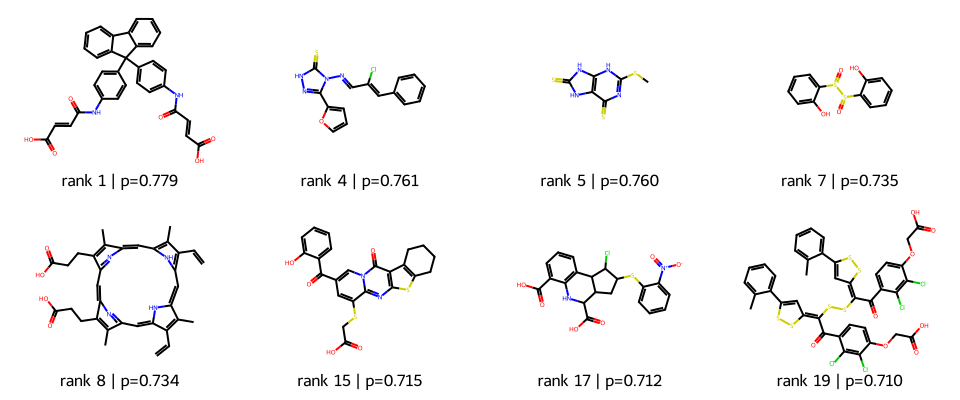

In [10]:
act = df[df.Active_v2==1].head(8)
mols=[Chem.MolFromSmiles(str(s)) for s in act["neut-smiles"]]
legs=[f"rank {int(r)} | p={p:.3f}" for r,p in zip(act["rank"], act.affinity_probability_binary)]
mols=[m for m in mols if m]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(240,200), legends=legs)

## Molecular property ranges of actives (all targets)
Heavy-atom count and MW — a sanity check on the compound libraries (the two excluded MF-PCBA assays were dropped for >60 heavy-atom actives / unspecified pockets).

In [11]:
rows=[]
for t, df in frames.items():
    a = df[df.Active_v2==1]
    hs, mws = [], []
    for s in a["neut-smiles"].head(200):
        m = Chem.MolFromSmiles(str(s))
        if m: hs.append(m.GetNumHeavyAtoms()); mws.append(Descriptors.MolWt(m))
    rows.append({"target": t, "protein": TARGETS[t][0],
                 "heavy_med": int(np.median(hs)), "heavy_max": int(np.max(hs)),
                 "MW_med": round(np.median(mws),1)})
pd.DataFrame(rows)

,target,protein,heavy_med,heavy_max,MW_med
0,588689,Dengue-2 NS5 MTase,27,58,408.9
1,540297-493091,SCP1 phosphatase,27,65,395.4
2,434954-2097,GSK-3β,22,32,316.3
3,463203-2650,GSK-3α,22,34,312.9
4,493248-485317,ALR / GFER oxidase,21,34,295.9
5,504329,Influenza A NS1,24,58,333.9
6,624273-588549,M.tb FadD28 ligase,28,37,404.4
7,1053173-743445,NSD2 PWWP1 domain,24,58,333.8


---
## More data visualizations

In [12]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold

def desc_frame(t, n_inact=1200, seed=0):
    df = pd.read_csv(DATA / f"{t}_results.csv")
    act = df[df.Active_v2 == 1]
    inact_all = df[df.Active_v2 == 0]
    ina = inact_all.sample(min(n_inact, len(inact_all)), random_state=seed)
    rows = []
    for _, r in pd.concat([act, ina]).iterrows():
        m = Chem.MolFromSmiles(str(r["neut-smiles"]))
        if m is None: continue
        rows.append(dict(active=int(r.Active_v2), MW=Descriptors.MolWt(m),
            HAC=m.GetNumHeavyAtoms(), cLogP=Descriptors.MolLogP(m),
            TPSA=rdMolDescriptors.CalcTPSA(m), HBD=Lipinski.NumHDonors(m),
            HBA=Lipinski.NumHAcceptors(m), RotB=Descriptors.NumRotatableBonds(m),
            Rings=rdMolDescriptors.CalcNumRings(m)))
    return pd.DataFrame(rows)


### Score separability by target
How well the off-the-shelf Boltz-2 score already separates actives from inactives, per target. The more the red (active) mass sits right of the grey (inactive), the easier the target.

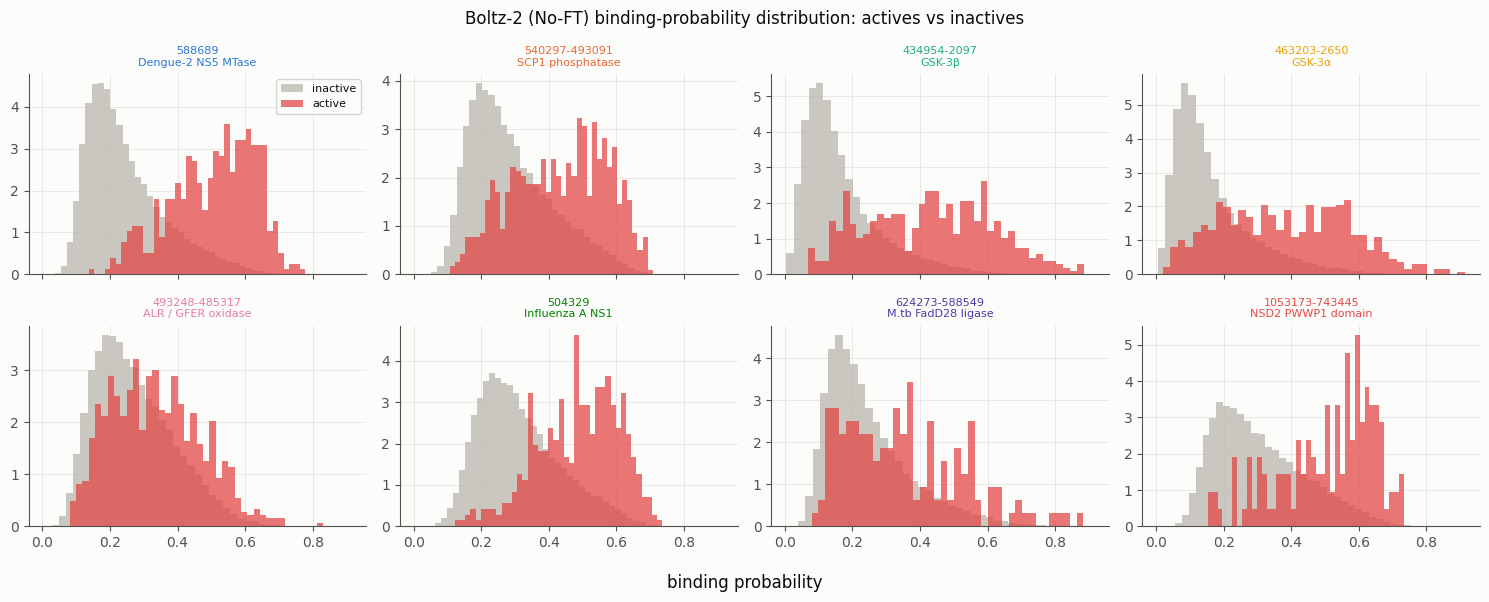

In [13]:
fig, axes = plt.subplots(2,4, figsize=(15,6), sharex=True)
for ax,(t,df) in zip(axes.ravel(), frames.items()):
    ax.hist(df[df.Active_v2==0].affinity_probability_binary, bins=40, density=True, color=INACTIVE, alpha=.75)
    ax.hist(df[df.Active_v2==1].affinity_probability_binary, bins=40, density=True, color=ACTIVE, alpha=.75)
    ax.set_title(f"{t}\n{TARGETS[t][0]}", fontsize=8, color=TCOLOR[t])
axes[0,0].legend(["inactive","active"], fontsize=8)
fig.suptitle("Boltz-2 (No-FT) binding-probability distribution: actives vs inactives", fontsize=12)
fig.supxlabel("binding probability"); plt.tight_layout(); plt.show()

### How good is the No-FT ranking already?
AUROC (separation) and EF@1% (early enrichment over random) for the off-the-shelf Boltz-2 score. This is the baseline that fine-tuning must beat \u2014 the paper reports geo-mean EF@1% rising from ~10.9 (No-FT) to ~19.6 at N=300.

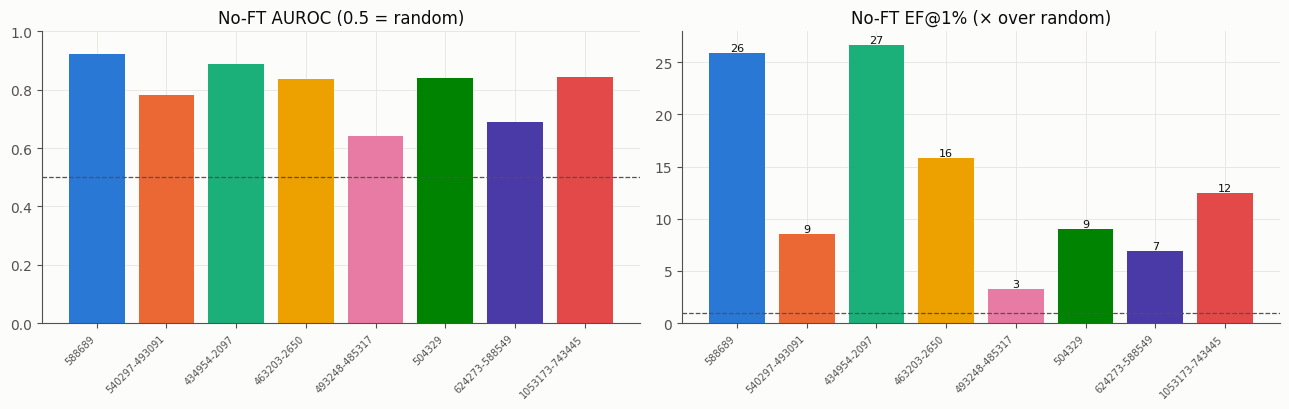

,target,auroc,ef1
0,588689,0.923,25.918
1,540297-493091,0.780,8.565
2,434954-2097,0.888,26.636
3,463203-2650,0.836,15.844
4,493248-485317,0.641,3.277
5,504329,0.839,9.010
6,624273-588549,0.690,6.916
7,1053173-743445,0.842,12.499


In [14]:
from sklearn.metrics import roc_auc_score
rows=[]
for t,df in frames.items():
    y=df.Active_v2.values.astype(int); s=df.affinity_probability_binary.values
    k=max(1,round(0.01*len(y))); order=np.argsort(-s)
    ef=float(y[order][:k].mean()/y.mean())
    rows.append(dict(target=t, auroc=roc_auc_score(y,s), ef1=ef))
mm=pd.DataFrame(rows)
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.2))
cols=[TCOLOR[t] for t in mm.target]; x=range(8)
a1.bar(x, mm.auroc, color=cols); a1.axhline(0.5,color=MUTED,ls="--",lw=.9)
a1.set_ylim(0,1); a1.set_title("No-FT AUROC (0.5 = random)")
a1.set_xticks(list(x)); a1.set_xticklabels(mm.target, rotation=45, ha="right", fontsize=7)
a2.bar(x, mm.ef1, color=cols); a2.axhline(1,color=MUTED,ls="--",lw=.9)
a2.set_title("No-FT EF@1% (\u00d7 over random)")
a2.set_xticks(list(x)); a2.set_xticklabels(mm.target, rotation=45, ha="right", fontsize=7)
for i,v in enumerate(mm.ef1): a2.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()
mm.round(3)

### Where do the actives sit in the ranking?
Histogram of active ranks (log x). Mass toward the left = early enrichment. Dashed line = the top-300 training cutoff (everything left of it is excluded from evaluation).

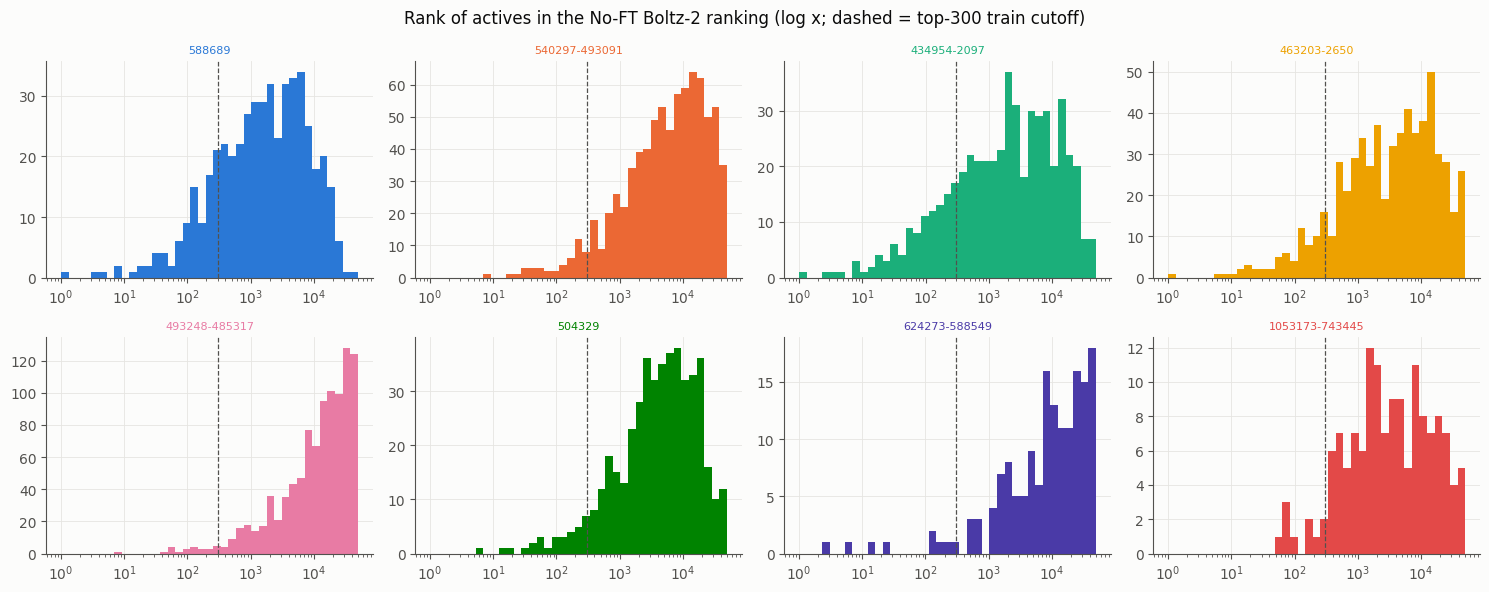

In [15]:
fig,axes=plt.subplots(2,4,figsize=(15,6))
for ax,(t,df) in zip(axes.ravel(), frames.items()):
    ranks=np.where(df.Active_v2.values==1)[0]+1
    ax.hist(ranks, bins=np.logspace(0, np.log10(len(df)), 40), color=TCOLOR[t])
    ax.set_xscale("log"); ax.axvline(300, color=MUTED, ls="--", lw=.9)
    ax.set_title(f"{t}", fontsize=8, color=TCOLOR[t])
fig.suptitle("Rank of actives in the No-FT Boltz-2 ranking (log x; dashed = top-300 train cutoff)", fontsize=12)
plt.tight_layout(); plt.show()

### Molecular property distributions: actives vs inactives
Pooled across all targets (sampled). Sanity check on the libraries and a look at what distinguishes binders physicochemically.

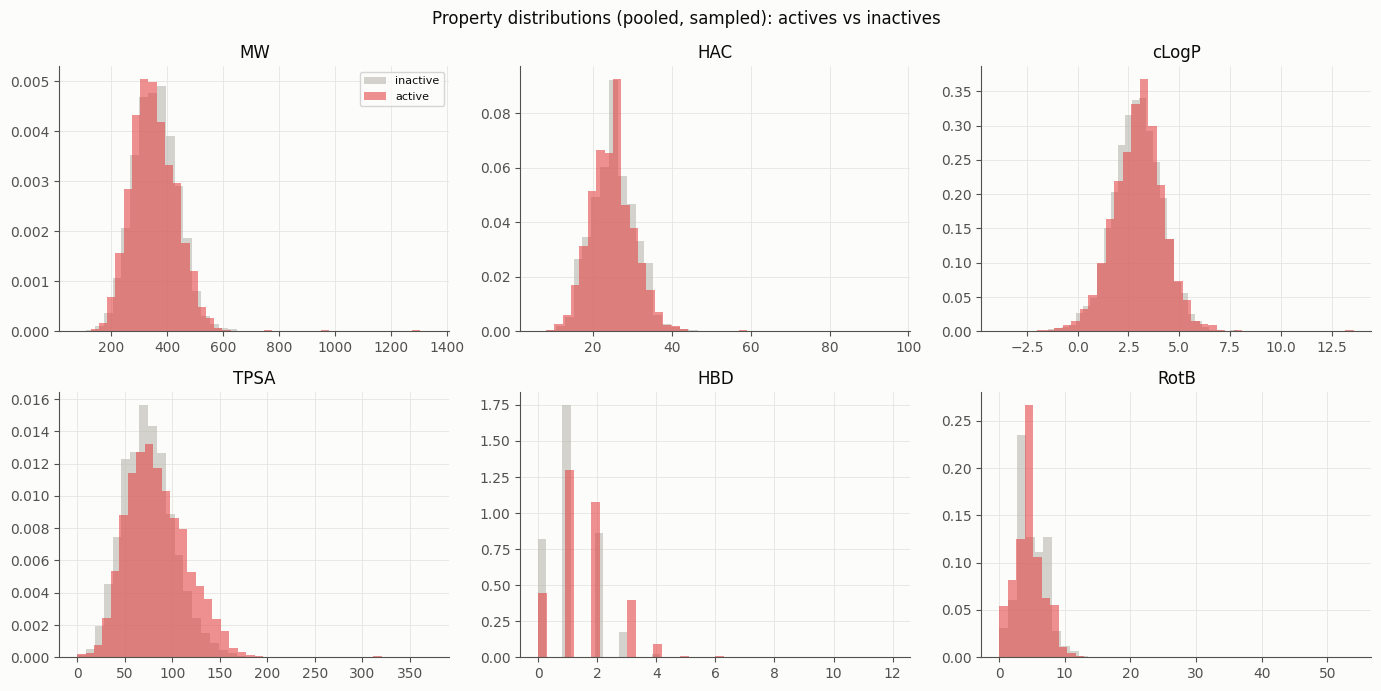

In [16]:
dall = pd.concat([desc_frame(t) for t in TARGETS], ignore_index=True)
props=["MW","HAC","cLogP","TPSA","HBD","RotB"]
fig,axes=plt.subplots(2,3,figsize=(14,7))
for ax,p in zip(axes.ravel(), props):
    for lab,c,v in [("inactive",INACTIVE,0),("active",ACTIVE,1)]:
        ax.hist(dall[dall.active==v][p].dropna(), bins=40, density=True, alpha=.6, color=c, label=lab)
    ax.set_title(p)
axes[0,0].legend(fontsize=8)
fig.suptitle("Property distributions (pooled, sampled): actives vs inactives", fontsize=12)
plt.tight_layout(); plt.show()

### Do the scoring methods agree? (588689)
Spearman correlation among the cached scores shipped with the data (Boltz-2, Boltzina, and, where available, GNINA/Vina). Low correlation = the methods rank compounds differently.

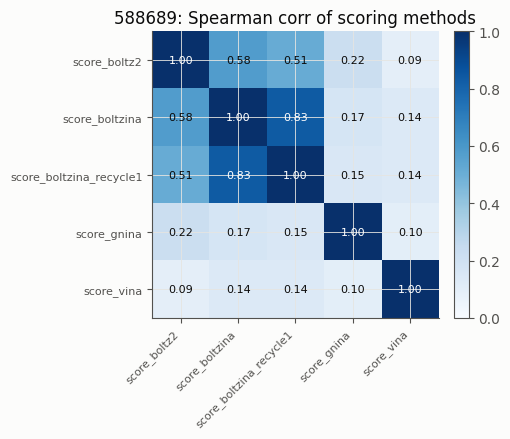

methods with data: ['score_boltz2', 'score_boltzina', 'score_boltzina_recycle1', 'score_gnina', 'score_vina']


In [17]:
raw = pd.read_csv(RAW / "588689.csv")
cand = ["score_boltz2","score_boltzina","score_boltzina_recycle1","score_gnina","score_vina"]
avail = [c for c in cand if c in raw and raw[c].notna().sum() > 100]
corr = raw[avail].corr(method="spearman")
fig,ax=plt.subplots(figsize=(5.5,4.5))
im=ax.imshow(corr.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(avail))); ax.set_xticklabels(avail, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(avail))); ax.set_yticklabels(avail, fontsize=8)
for i in range(len(avail)):
    for j in range(len(avail)):
        ax.text(j,i,f"{corr.values[i,j]:.2f}",ha="center",va="center",fontsize=8,
                color=("white" if corr.values[i,j]>0.6 else INK))
fig.colorbar(im, fraction=0.046, pad=0.04); ax.set_title("588689: Spearman corr of scoring methods")
plt.tight_layout(); plt.show()
print("methods with data:", avail)

### Scaffold diversity among actives
Unique Bemis\u2013Murcko scaffolds divided by number of actives, per target. Higher = the actives are more chemically diverse (harder for a similarity/scaffold prior); lower = a few dominant chemotypes.

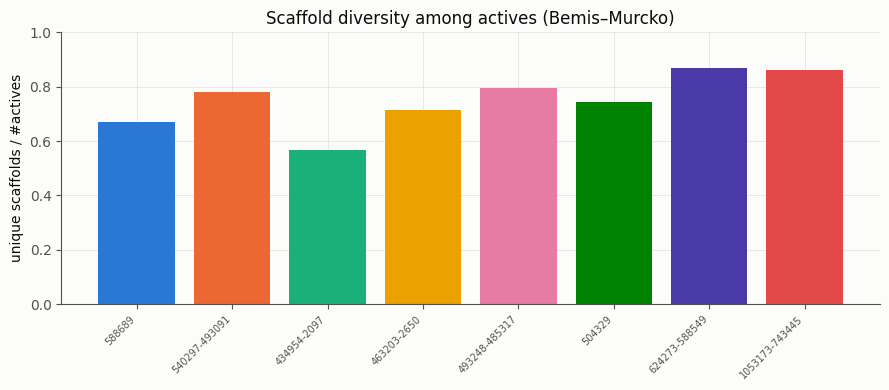

,target,n_active,n_scaffold,frac
0,588689,486,326,0.670782
1,540297-493091,782,610,0.780051
2,434954-2097,522,296,0.567050
3,463203-2650,612,436,0.712418
4,493248-485317,976,775,0.794057
5,504329,466,347,0.744635
6,624273-588549,159,138,0.867925
7,1053173-743445,144,124,0.861111


In [18]:
rows=[]
scaf_by_target={}
for t,df in frames.items():
    act=df[df.Active_v2==1]
    scafs=[]
    for s in act["neut-smiles"]:
        m=Chem.MolFromSmiles(str(s))
        if m: scafs.append(MurckoScaffold.MurckoScaffoldSmiles(mol=m))
    scaf_by_target[t]=scafs
    u=len(set(scafs))
    rows.append(dict(target=t, n_active=len(act), n_scaffold=u, frac=u/max(1,len(act))))
sc=pd.DataFrame(rows)
fig,ax=plt.subplots(figsize=(9,4))
ax.bar(range(8),[sc.frac[i] for i in range(8)],color=[TCOLOR[t] for t in sc.target])
ax.set_xticks(range(8)); ax.set_xticklabels(sc.target, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("unique scaffolds / #actives"); ax.set_ylim(0,1)
ax.set_title("Scaffold diversity among actives (Bemis\u2013Murcko)")
plt.tight_layout(); plt.show()
sc

### Most common active scaffolds (588689)
The dominant chemotypes among confirmed binders for the lead target.

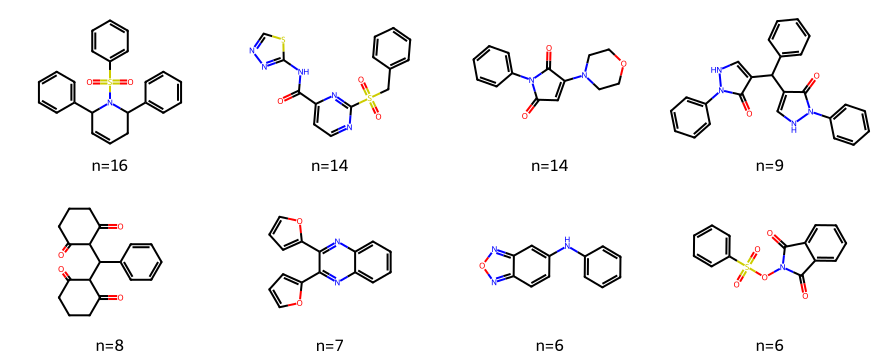

In [19]:
from collections import Counter
cnt=Counter(s for s in scaf_by_target["588689"] if s)
common=cnt.most_common(8)
mols=[Chem.MolFromSmiles(sm) for sm,_ in common]
pairs=[(m,f"n={n}") for (m),( _,n) in zip(mols,common) if m]
Draw.MolsToGridImage([m for m,_ in pairs], molsPerRow=4, subImgSize=(220,180),
                     legends=[l for _,l in pairs])